In [1]:
from glacierview import config

# Committed reference data lives at the repo root, resolved from the
# package so this works wherever Jupyter was started.
ANALYSIS_DIR = config.ANALYSIS_DIR
assert ANALYSIS_DIR.is_dir(), f"not found: {ANALYSIS_DIR}"

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

predicted_no_thresh = pd.read_excel(ANALYSIS_DIR / "areas_binary_05_filtered_smooth_f.xlsx").drop("Dates",axis=1)
predicted_no_thresh

,Dates.1,G007026E45991N,G007045E45994N,G007050E45972N,G007060E45918N,G007068E45470N,G007216E46320N,G007257E45892N,G007260E45523N,G007261E45966N,...,G290562E33040S,G290597E32946S,G291093E27916S,G291148E82396N,G291152E27715S,G291155E27738S,G291223E27753S,G292417E82497N,G292942E82564N,G293549E82381N
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1979-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1979-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,2023-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1078,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1079,2023-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1080,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# predicted_no_thresh = pd.read_csv("areas_binary_05_fil_smooth.csv").drop("Dates",axis=1)
# predicted_no_thresh = pd.read_csv("areas_binary_05_smooth3d.csv").drop("Dates",axis=1)
# predicted_no_thresh = pd.read_csv(ANALYSIS_DIR / "areas_binary_05_filtered_smooth_25.csv").drop("Dates",axis=1)
predicted_no_thresh = pd.read_excel(ANALYSIS_DIR / "areas_binary_05_filtered_smooth_f.xlsx").drop("Dates",axis=1)
predicted_no_thresh["Dates"] = pd.to_datetime(predicted_no_thresh["Dates.1"])
predicted_no_thresh.index = pd.to_datetime(predicted_no_thresh["Dates"])
predicted_glaciers = predicted_no_thresh.columns[1:].to_list()
predicted_no_thresh=predicted_no_thresh.groupby(pd.PeriodIndex(predicted_no_thresh.index, freq="Y")).mean(numeric_only=True)
predicted_no_thresh["Dates"]=predicted_no_thresh.index
predicted_no_thresh = predicted_no_thresh.iloc[:,2:]
predicted_no_thresh

,G007050E45972N,G007060E45918N,G007068E45470N,G007216E46320N,G007257E45892N,G007260E45523N,G007261E45966N,G007262E45536N,G007270E45507N,G007276E45539N,...,G290597E32946S,G291093E27916S,G291148E82396N,G291152E27715S,G291155E27738S,G291223E27753S,G292417E82497N,G292942E82564N,G293549E82381N,Dates
Dates,,,,,,,,,,,,,,,,,,,,,
1979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1979
1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1980
1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981
1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1982
1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1983
1984,9.331684,1.483615,2.986256,3.254803,2.285574,1.962322,1.854387,1.405914,1.411905,1.199396,...,3.314783,3.605868,NaN,11.373703,11.480489,4.353641,NaN,NaN,NaN,1984
1985,9.331179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.605301,NaN,11.373703,11.483434,4.354013,NaN,NaN,NaN,1985
1986,9.341041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.316969,3.600090,NaN,11.378982,11.516933,4.361132,NaN,NaN,NaN,1986
1987,9.377892,1.483309,2.986256,3.255100,2.285834,1.963020,1.854858,1.405916,1.411903,1.199593,...,3.321416,3.592466,NaN,11.382914,11.578885,4.374627,NaN,NaN,NaN,1987


In [4]:
training_areas=pd.read_csv(ANALYSIS_DIR / "training_areas.csv")
training_areas.columns=training_areas.iloc[0]
training_areas=training_areas.drop([0])
training_areas=training_areas.drop(columns=[0])
training_areas

training_dates = pd.read_csv(ANALYSIS_DIR / "training_data_set.csv")
training_dates[training_dates.glims_id=="G007800E45965N"]
training_areas_final = training_dates.join(training_areas.T, on="glims_id", how="right")
training_areas_final["Dates"]=pd.DatetimeIndex(training_areas_final["file_name"].apply(lambda x: x[15:25]))
training_areas_final = training_areas_final[["glims_id","Dates",1]].reset_index(drop=True)
training_areas_final = training_areas_final.rename(columns={1: "Areas"})
training_areas_final

,glims_id,Dates,Areas
0,G007800E45965N,2009-09-07,40.24113082885742
1,G007807E46481N,2009-09-30,12.224644660949707
2,G284068E81599N,2015-07-17,1.3720623254776
3,G286738E50402S,2005-04-01,9.8292236328125
4,G009860E46370N,2009-09-07,6.794958591461182
...,...,...,...
254,G075248E38558N,2009-07-26,44.82341384887695
255,G286852E49174S,2005-02-19,16.92928123474121
256,G286929E49140S,2005-02-19,11.652968406677246
257,G041406E43354N,2014-09-02,1.624479055404663


In [5]:
geo_areas = pd.read_csv(ANALYSIS_DIR / "geo_areas.csv")
geo_areas=geo_areas[["glac_id","geog_area_rollup"]]#.groupby("geog_area_rollup")
geo_areas.head()

,glac_id,geog_area_rollup
0,G282389E08980S,South America
1,G282412E08893S,South America
2,G282374E08986S,South America
3,G282395E08861S,South America
4,G282346E09032S,South America


/var/folders/7v/wqws57wd0mnbj5r_9k6lb91c0000gn/T/ipykernel_53632/2175721773.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  abs_error = abs(float(mvst_area.iloc[:,0])-mvst_area[glacier])
/var/folders/7v/wqws57wd0mnbj5r_9k6lb91c0000gn/T/ipykernel_53632/2175721773.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rel_error = 100*(abs(float(mvst_area["Areas"])-mvst_area[glacier]))/float(mvst_area["Areas"])
/var/folders/7v/wqws57wd0mnbj5r_9k6lb91c0000gn/T/ipykernel_53632/2175721773.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  abs_error = abs(float(mvst_area.iloc[:,0])-mvst_area[glacier])
/var/folders/7v/wqws57wd0mnbj5r_9k6lb91c0000gn/T/ipykernel_53632/2175721773.py:14: FutureWarning

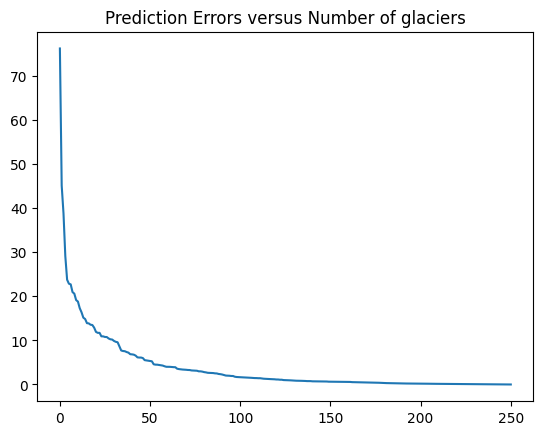

In [7]:
# Prediction error from training data
# predicted_no_thresh = pd.read_excel("areas_binary_05.xlsx").drop("Dates",axis=1).rename(columns={"Dates.1":"Dates"})
errors = []
for glacier in predicted_glaciers[:]:
    try:
        glacier_df = predicted_no_thresh[["Dates",glacier]].dropna()
        temp= training_areas_final[training_areas_final.glims_id==glacier]
        mvst_area = pd.merge(temp,glacier_df,
                 left_on=temp["Dates"].apply(lambda x: (x.year)),
                 right_on=glacier_df["Dates"].apply(lambda x: (x.year)),how="left")[["Areas",glacier]]
        # print(mvst_area)

        abs_error = abs(float(mvst_area.iloc[:,0])-mvst_area[glacier])
        rel_error = 100*(abs(float(mvst_area["Areas"])-mvst_area[glacier]))/float(mvst_area["Areas"])
        # print("True Area: ",float(mvst_area.iloc[:,0]),"Predicted: ",mvst_area.iloc[:,1].values[0],"Err: ",error[0])

        errors.append((glacier,abs_error.values[0], rel_error.values[0]))
        # print((glacier,error.values[0]))
    except Exception:
        pass
training_err = pd.DataFrame(errors)
training_err = training_err.sort_values(by=1)
training_err = training_err.rename(columns={0:"glims_id",1:"abs_error_train",2:"rel_error_train"})
training_err=training_err.sort_values(by="abs_error_train",ascending=False).reset_index(drop=True)
training_err["abs_error_train"].plot()
plt.title("Prediction Errors versus Number of glaciers")


Regression Statistics for South America:
Slope SE: 0.0009
Intercept SE: 0.0581
Percentage decline since beginning: -3.1076%



<Figure size 1000x500 with 0 Axes>

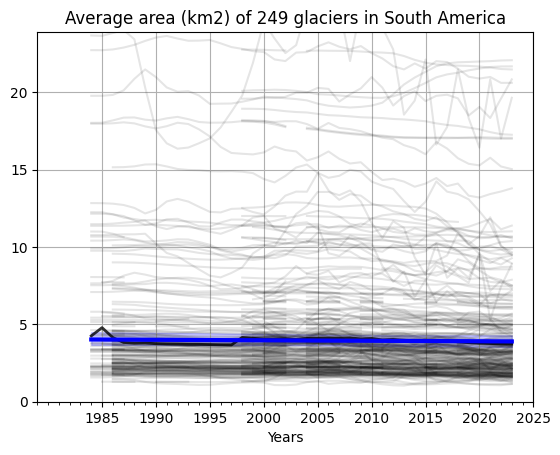


Regression Statistics for Asia:
Slope SE: 0.0002
Intercept SE: 0.0291
Percentage decline since beginning: -7.1474%



<Figure size 1000x500 with 0 Axes>

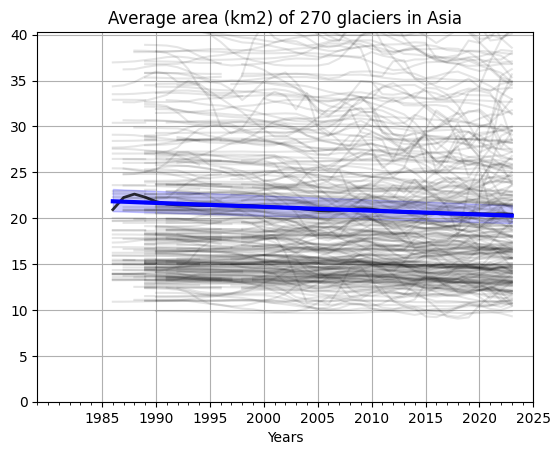


Regression Statistics for Europe:
Slope SE: 0.0004
Intercept SE: 0.0636
Percentage decline since beginning: -16.3851%



<Figure size 1000x500 with 0 Axes>

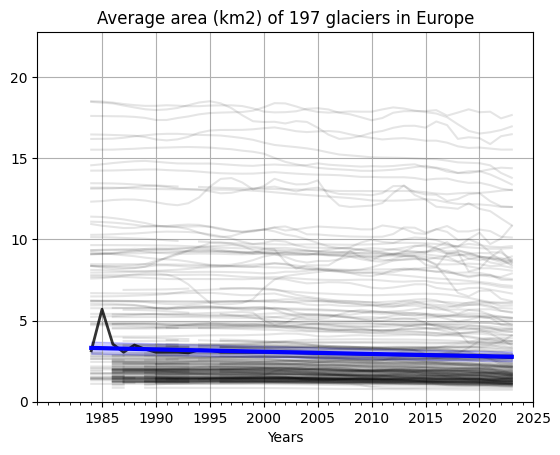


Regression Statistics for North America:
Slope SE: 0.0011
Intercept SE: 0.0450
Percentage decline since beginning: -2.1649%



<Figure size 1000x500 with 0 Axes>

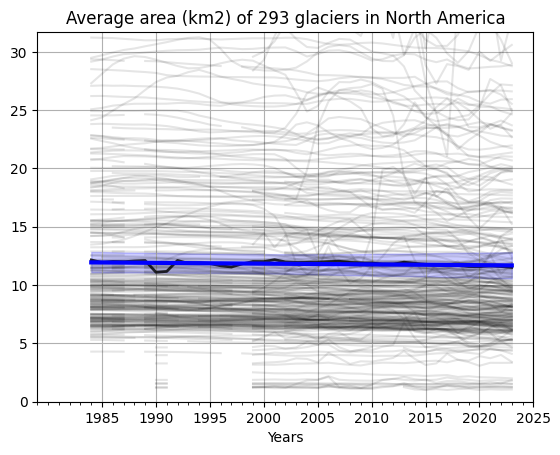


Regression Statistics for Caucausus:
Slope SE: 0.0003
Intercept SE: 0.0519
Percentage decline since beginning: -8.9065%



<Figure size 1000x500 with 0 Axes>

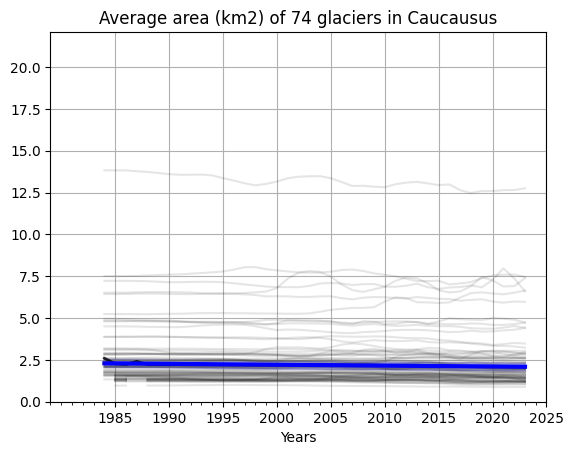

In [9]:
# Final for Linear Regression on all glaciers - Somansh AUg 5th 2025

import datetime
import math

import numpy as np
import seaborn as sns
import statsmodels.api as sm
from scipy import stats


def bootstrap_regression_glaciers(glacier_data, years, n_iterations=100):
    n_glaciers = len(glacier_data.columns)
    predictions = np.zeros((n_iterations, len(years)))
    slopes = []
    intercepts = []

    for i in range(n_iterations):
        # Sample glaciers with replacement
        sampled_glaciers = np.random.choice(glacier_data.columns, size=n_glaciers, replace=True)
        sample_data = glacier_data[sampled_glaciers]

        df = sample_data
        df.index.name = 'year'
        df_long = df.reset_index().melt(id_vars='year', var_name='glacier', value_name='area').dropna()


        # Calculate mean of sampled glaciers and weights based on data availability
        # mean_log_areas = sample_data.mean(axis=1, numeric_only=True).dropna()

        # Calculate weights based on proportion of non-missing data
        # weights = (sample_data.notna().sum(axis=1) / n_glaciers).loc[mean_log_areas.index]

        # Prepare data for regression
        # valid_years = mean_log_areas.index.astype(int).values
        # valid_data = mean_log_areas.values

        valid_years = df_long["year"].astype(int).values
        valid_data = df_long["area"].values

        # Skip iteration if we don't have enough valid data points
        if len(valid_data) < 2:
            continue

        # Fit weighted least squares regression
        X = sm.add_constant(valid_years)
        model = sm.OLS(valid_data, X)
        try:
            results = model.fit()

            # Store coefficients
            intercepts.append(results.params[0])
            slopes.append(results.params[1])

            # Generate predictions for all years
            X_full = sm.add_constant(years)
            predictions[i, :] = results.predict(X_full)
        except Exception:
            continue

    # Remove any zero rows from failed iterations
    predictions = predictions[~np.all(predictions == 0, axis=1)]

    # Calculate confidence intervals
    ci_lower = np.percentile(predictions, 2.5, axis=0)
    ci_upper = np.percentile(predictions, 97.5, axis=0)

    # Calculate standard errors
    slope_se = np.std(slopes)
    intercept_se = np.std(intercepts)

    # Calculate mean prediction
    mean_prediction = np.mean(predictions, axis=0)

    return {
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'slope_se': slope_se,
        'intercept_se': intercept_se,
        'slopes': slopes,
        'intercepts': intercepts,
        'mean_prediction': mean_prediction
    }

def plot_areas(rel_error=8, log=True, all_areas=False, weighted=False):
    slopes = []
    areas = ['South America', 'Asia', 'Europe', 'North America', 'Caucausus', 'Oceania']
    better_glaciers = training_err[training_err["rel_error_train"] < rel_error]

    for area in areas[:-1]:
        try:
            plt.figure(figsize=(10, 5))
            selected_glaciers = geo_areas.groupby("geog_area_rollup").get_group(area)["glac_id"].to_list()
            selected_glaciers = list(set(selected_glaciers).intersection(set(predicted_glaciers)))

            final_filtered_glaciers = []
            for i in selected_glaciers:
                if i in list(predicted_no_thresh.columns):
                    final_filtered_glaciers.append(i)

            selected_glaciers = final_filtered_glaciers
            num_glaciers = len(selected_glaciers)

            if num_glaciers == 0:
                print(f"No glaciers found for {area}")
                continue

            # Get data for selected glaciers
            ng = predicted_no_thresh[selected_glaciers]
            log_areas = ng.apply(np.log)

            # Get years where we have any data
            data_availability = ng.notna().sum(axis=1)
            valid_years_mask = data_availability > 0
            valid_years = ng.index[valid_years_mask].astype(int).values

            # Calculate and display data availability
            data_availability_pct = (data_availability / num_glaciers * 100).round(2)
            # print(f"\nData Availability for {area}:")
            # print("Year  | % Glaciers with Data")
            # print("-" * 30)
            # for year, avail in zip(valid_years, data_availability_pct[valid_years_mask]):
            #     print(f"{year} | {avail:>6.2f}%")

            # Perform bootstrap on individual glacier data
            bootstrap_results = bootstrap_regression_glaciers(log_areas, valid_years)

            if not log:
                # Transform predictions and confidence intervals back to original scale
                y_pred = np.exp(bootstrap_results['mean_prediction'])
                ci_lower = np.exp(bootstrap_results['ci_lower'])
                ci_upper = np.exp(bootstrap_results['ci_upper'])

                print(f"\nRegression Statistics for {area}:")
                print(f"Slope SE: {bootstrap_results['slope_se']:.4f}")
                # print(f"CI: {ci_lower},{ci_upper}")
                print(f"Intercept SE: {bootstrap_results['intercept_se']:.4f}")
                print(f"Percentage decline since beginning: {round((100*(y_pred[-1]-y_pred[0])/y_pred[0]),4)}%\n")
                slopes.append(round(((y_pred[-1]-y_pred[0])/y_pred[0]),4))

                # Plot original data
                ng.plot(alpha=0.1, legend=False, color="black")
                np.exp(np.log(ng).mean(axis=1, numeric_only=True)).dropna().plot(alpha=0.8, legend=False, lw=2, color="black")

                # Plot regression line and confidence bands only for valid years
                plt.plot(valid_years, y_pred, alpha=1, lw=3, color="blue", label='Regression line')
                plt.fill_between(valid_years, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% CI')


            else:
                print(f"\nRegression Statistics for {area}:")
                print(f"Slope SE: {bootstrap_results['slope_se']:.4f}")
                print(f"Intercept SE: {bootstrap_results['intercept_se']:.4f}")

                # Plot original data
                log_areas.plot(alpha=0.1, legend=False, color="black")
                log_areas.mean(axis=1, numeric_only=True).dropna().plot(alpha=0.8, legend=False, lw=2, color="black")

                # Plot regression line and confidence bands only for valid years
                plt.plot(valid_years, bootstrap_results['mean_prediction'], alpha=1, lw=3, color="blue", label='Regression line')
                plt.fill_between(valid_years, bootstrap_results['ci_lower'], bootstrap_results['ci_upper'],
                               color='blue', alpha=0.2, label='95% CI')

            plt.xlabel("Years")
            plt.title(f"Average area (km2) of {num_glaciers} glaciers in {area}")
            plt.grid(True)
            plt.ylim((0,y_pred.min()+20))
            plt.xticks(list(range(15,60,5)), [i+1970 for i in range(15,60,5)])
            plt.savefig(f"plots_glacier/new_{area}_reg")
            plt.show()

        except Exception as e:
            print(f"Error processing {area}: {e!s}")
    return slopes

avg_slopes = plot_areas(rel_error=200, log=False)

Error processing South America: name 'avg_slopes' is not defined
Error processing Asia: name 'avg_slopes' is not defined
Error processing Europe: name 'avg_slopes' is not defined
Error processing North America: name 'avg_slopes' is not defined
Error processing Caucausus: name 'avg_slopes' is not defined


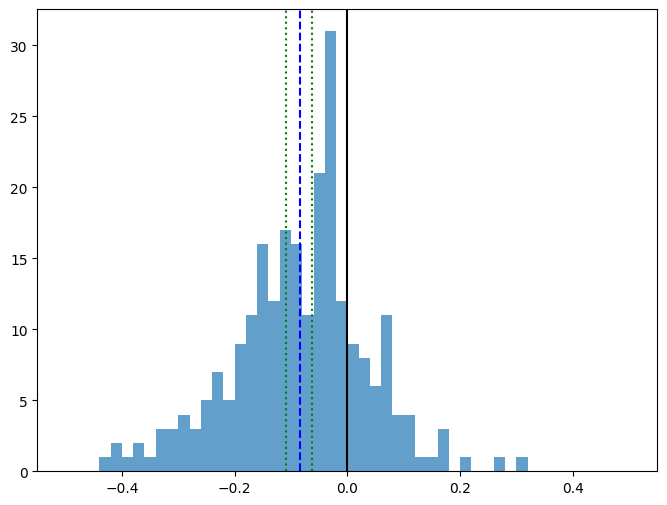

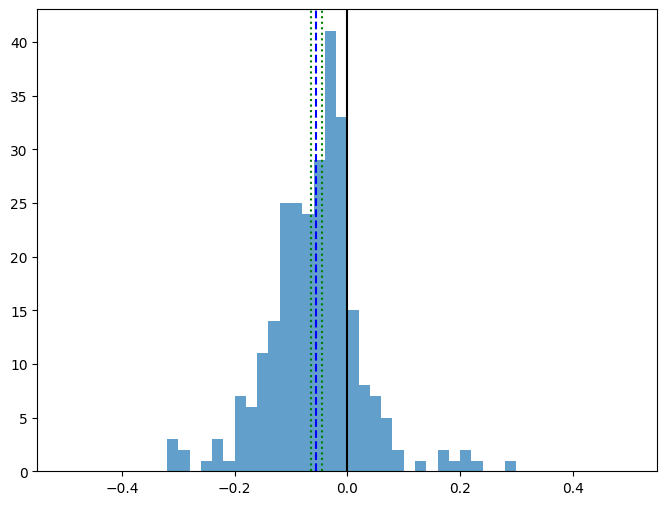

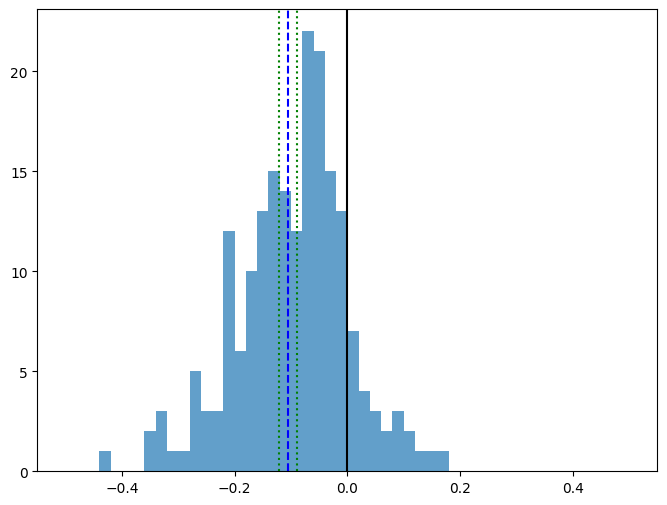

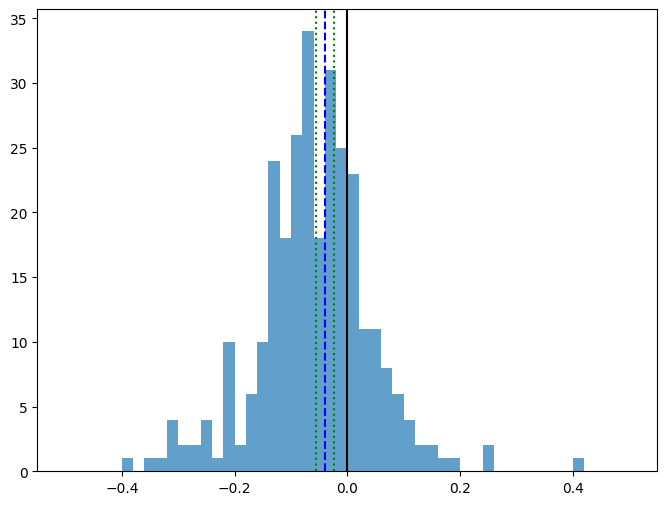

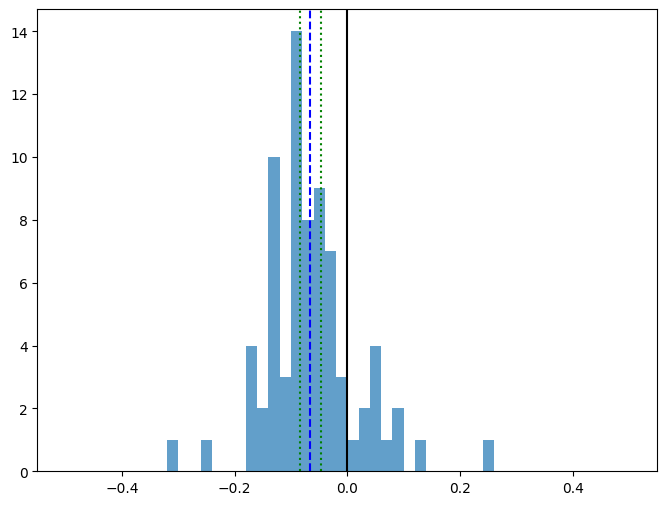

In [8]:
# Final from Somansh - AUg 5th 2025 - for drawing the Time Series Analysis - Slope Disrtibution.

import datetime
import math

import numpy as np
import seaborn as sns
import statsmodels.api as sm


def bootstrap_glacier_slopes(glacier_data, n_iterations=500):
    n_glaciers = len(glacier_data.columns)
    total_rows = glacier_data.shape[0]
    all_bootstrap_slopes = []

    for _ in range(n_iterations):
        # Sample glaciers with replacement
        sampled_glaciers = np.random.choice(glacier_data.columns, size=n_glaciers, replace=True)
        slopes_iteration = []
        weights_iteration = []

        # Calculate slope for each sampled glacier
        for glacier in sampled_glaciers:
            glacier_areas = np.log(glacier_data[glacier]).dropna()
            if len(glacier_areas) < 2:  # Skip if not enough data points
                continue

            x = glacier_areas.index.astype(int).to_list()
            log_y = glacier_areas.to_list()

            x_matrix = sm.add_constant(x)
            model = sm.OLS(log_y, x_matrix)
            results = model.fit()

            # Scale slope by time period
            slope = results.params[1] * (max(x) - min(x))
            slopes_iteration.append(slope)

            # Calculate weight based on data availability
            weights_iteration.append((total_rows - len(x))/total_rows)

        if slopes_iteration:  # Only if we got valid slopes
            weighted_avg = np.average(slopes_iteration, weights=weights_iteration)
            all_bootstrap_slopes.append(weighted_avg)

    return np.array(all_bootstrap_slopes)

def rel_decline(rel_error=8, log=True, all_areas=False, weighted=False):
    areas = ['South America', 'Asia', 'Europe', 'North America', 'Caucausus', 'Oceania']
    better_glaciers = training_err[training_err["rel_error_train"] < rel_error]

    for index,area in enumerate(areas[:-1]):
        try:
            # Get selected glaciers
            selected_glaciers = geo_areas.groupby("geog_area_rollup").get_group(area)["glac_id"].to_list()
            selected_glaciers = list(set(selected_glaciers).intersection(set(predicted_glaciers)))
            final_filtered_glaciers = []
            for i in selected_glaciers:
                if i in list(predicted_no_thresh.columns):
                    final_filtered_glaciers.append(i)

            selected_glaciers = final_filtered_glaciers
            num_glaciers = len(selected_glaciers)

            if num_glaciers == 0:
                print(f"No glaciers found for {area}")
                continue

            # Get glacier data
            ng = predicted_no_thresh[selected_glaciers]

            # Calculate original slopes for comparison
            total_rows = ng.shape[0]
            original_slopes = []
            weights = []

            for col in ng.columns:
                glacier_areas = np.log(ng[col]).dropna()
                if len(glacier_areas) < 2:
                    continue

                x = glacier_areas.index.astype(int).to_list()
                log_y = glacier_areas.to_list()

                x_matrix = sm.add_constant(x)
                model = sm.OLS(log_y, x_matrix)
                results = model.fit()

                slope = results.params[1] * (max(x) - min(x))
                original_slopes.append(slope)
                weights.append((total_rows - len(glacier_areas))/total_rows)

            # Perform bootstrap
            bootstrap_slopes = bootstrap_glacier_slopes(ng)

            # Calculate statistics
            original_weighted_avg = np.average(original_slopes, weights=weights)
            confidence_interval = np.percentile(bootstrap_slopes, [2.5, 97.5])

            # Create histogram plot
            plt.figure(figsize=(8, 6))

            # Plot histogram of original slopes
            _n, _bins, _patches = plt.hist(original_slopes, bins=50, range=(-0.5, 0.5),
                                      alpha=0.7, label='Original slopes')

            # Add vertical lines
            plt.axvline(x=0, color='black', linestyle='-', label='Zero line')
            plt.axvline(x=original_weighted_avg, color='blue', linestyle='--',
                       label=f'Weighted average: {original_weighted_avg:.3f}')
            plt.axvline(x=confidence_interval[0], color='green', linestyle=':',
                       label=f'95% CI: [{confidence_interval[0]:.3f}, {confidence_interval[1]:.3f}]')
            plt.axvline(x=confidence_interval[1], color='green', linestyle=':')
            plt.axvline(x=avg_slopes[index], color='red', label='Avg slope using Log-areas')


            # Count outliers
            # outliers = len([s for s in original_slopes if s < -0.5 or s > 0.5])

            # Add labels and customize plot
            plt.xlabel('Slope')
            plt.ylabel('Count')
            plt.title(f'Slope Distribution for {area}')
            plt.xlim(-0.5, 0.5)
            plt.legend()

            # Statistics output
            print(f"\nStatistics for {area}:")
            print(f"Number of glaciers: {num_glaciers}")
            print(f"Positive slopes: {sum(np.array(original_slopes) > 0)}")
            print(f"Weighted average slope: {original_weighted_avg:.4f}")
            print(f"95% Confidence Interval: [{confidence_interval[0]:.4f}, {confidence_interval[1]:.4f}]")
            print(f"Slope of all glaciers calculated using regression method: {avg_slopes[index]}")

            plt.savefig(f"plots_glacier/new_plot2_{area}")
            plt.show()

        except Exception as e:
            print(f"Error processing {area}: {e!s}")

# Run the analysis
rel_decline(rel_error=200, log=True)

# Apply it on log scale
# Also add the fitted slope line in this diagram as well, along with the standard error.